In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../')

from src.internal.extended_common import (
    CoordinateFrame,
    Pose, State,
    ExtendedConfig,
    KITTI_SEQUENCE_TO_DATE,
    KITTI_SEQUENCE_TO_DRIVE
)
from src.internal.dataset import OXTS_GPSDataReader, OXTS_IMUDataReader
from src.common.datatypes import State, Pose
from src.utils.geometric_transformer import GeometryTransformer, TransformationField, KITTI_GeometricTransformer
from src.utils.geometric_transformer.base_geometric_transformer import BaseGeometryTransformer


In [2]:
config = ExtendedConfig(config_filepath="/Volumes/Data_EXT/data/workspaces/sensor_fusion/notebooks/KITTI/config_files/config_kitti_ml.yaml")

kitti_transformer = KITTI_GeometricTransformer(
    hardware_config=config.hardware,
)


oxts_imu
kitti_stereo
kitti_vo


In [3]:
def get_kitti_dataset(
    root_path = "/Volumes/Data_EXT/data/workspaces/sensor_fusion/data/KITTI/",
    drive = "0033"
    ):
    
    gps_data_reader = OXTS_GPSDataReader(
        root_path=root_path,
        date="2011_09_30",
        drive=drive
    )
    
    imu_data_reader = OXTS_IMUDataReader(
        root_path=root_path,
        date="2011_09_30",
        drive=drive
    )
    
    gps_data = iter(gps_data_reader)
    gps = []
    ts = []
    while True:
      try:
          _data = next(gps_data)
          if _data is not None:
            ts.append(_data.timestamp)
            gps.append([_data.lon, _data.lat, _data.alt])
      except StopIteration:
          break
    
    imu_data = iter(imu_data_reader)
    imu = []
    
    while True:
        try:
            _data = next(imu_data)
            if _data is not None:
                temp = _data.a.tolist()
                temp.extend(_data.w.tolist())
                imu.append(temp)
        except StopIteration:
            break
    
    gps = np.array(gps)
    ts = np.array(ts)
    imu = np.array(imu)
    return gps, imu, ts

In [4]:
gps, imu, ts = get_kitti_dataset(
    root_path="/Volumes/Data_EXT/data/workspaces/sensor_fusion/data/KITTI/",
    drive="0033"
)

gps_test, imu_test, ts_test = get_kitti_dataset(
    root_path="/Volumes/Data_EXT/data/workspaces/sensor_fusion/data/KITTI/",
    drive="0034"
)


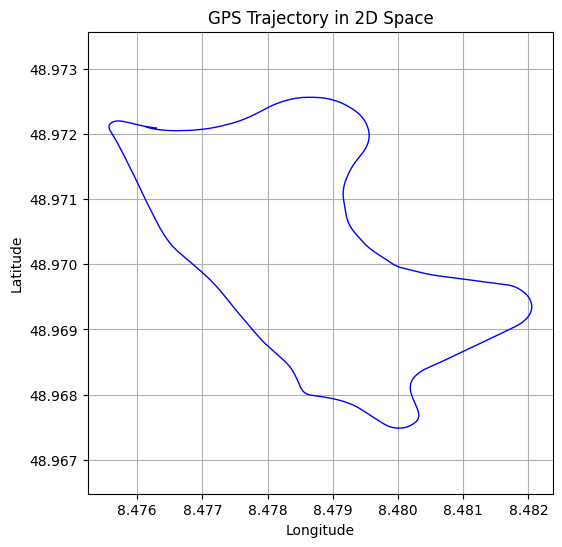

In [5]:
def visualize_gps(gps):
    """
    Visualizes GPS data in 2D space.
    
    Parameters:
    gps (np.ndarray): Array of GPS coordinates with shape (N, 3) where N is the number of points.
                      Each point is represented as [longitude, latitude, altitude].
    """
    if gps.shape[1] != 3:
        raise ValueError("GPS data must have shape (N, 3) where N is the number of points.")
    
    plt.figure(figsize=(6, 6))
    plt.plot(gps[:, 0], gps[:, 1], linestyle='-', color='b', linewidth=1)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('GPS Trajectory in 2D Space')
    plt.grid(True)
    plt.axis('equal')
    plt.show()

visualize_gps(gps)

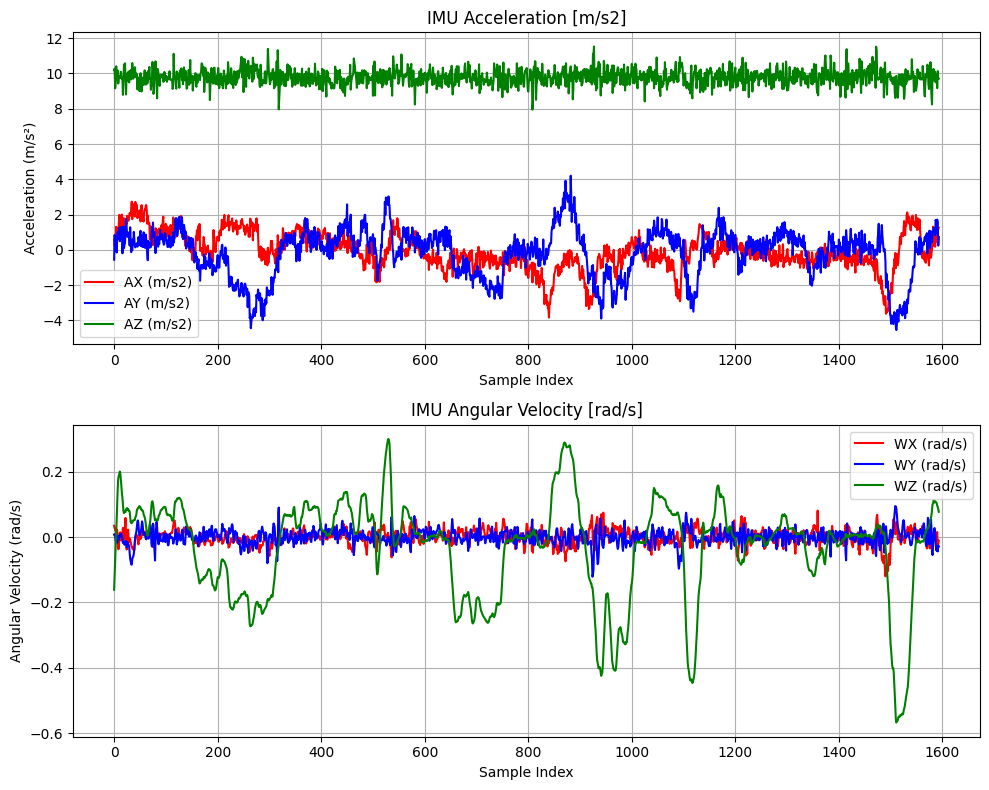

In [6]:
def visualize_imu(imu):
    """
    Visualizes IMU data in 2D space.
    
    Parameters:
    imu (np.ndarray): Array of IMU data with shape (N, 2) where N is the number of points.
                      Each point is represented as [acceleration, angular velocity].
    """
    
    color_axis = ['red', 'blue', 'green']
    axis_labels = ['X', 'Y', 'Z']
    
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))
    for i in range(3):
        axs[0].plot(imu[:, i], label=f'A{axis_labels[i]} (m/s2)', color=color_axis[i])
        axs[1].plot(imu[:, 3+i], label=f'W{axis_labels[i]} (rad/s)', color=color_axis[i])

    axs[0].set_title('IMU Acceleration [m/s2]')
    axs[0].set_xlabel('Sample Index')
    axs[0].set_ylabel('Acceleration (m/s²)')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].set_title('IMU Angular Velocity [rad/s]')
    axs[1].set_xlabel('Sample Index')
    axs[1].set_ylabel('Angular Velocity (rad/s)')
    axs[1].legend()
    axs[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    

visualize_imu(imu)

In [7]:
gps.shape

(1594, 3)

# Create machine learning model to predict GPS data

In [8]:
state = State(p=np.zeros(3), 
              v=np.zeros(3), 
              q=np.array([1, 0, 0, 0]), 
              b_a=np.zeros(3), 
              b_w=np.zeros(3))

gps_m = []
for i in range(gps.shape[0]):
    _gps = gps[i]
    
    _gps_t = kitti_transformer.transform_data(fields=TransformationField(
            state=state,
            value=_gps,
            coord_from=CoordinateFrame.GPS,
            coord_to=CoordinateFrame.INERTIAL))
    gps_m.append(_gps_t.flatten())

gps_m = np.array(gps_m)

data_end = 500
gps_m_delta = gps_m[1:] - gps_m[:-1]
gps_train = gps_m_delta[:data_end]
imu_train = imu[:data_end]
dt = ts[1:] - ts[:-1]
ts_train = dt[:data_end]

In [9]:
device = "mps" if torch.mps.is_available() else "cpu"

## Classical ML approach

In [10]:
class NN(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 3)  # Δp
        )

    def forward(self, x):
        return self.net(x)

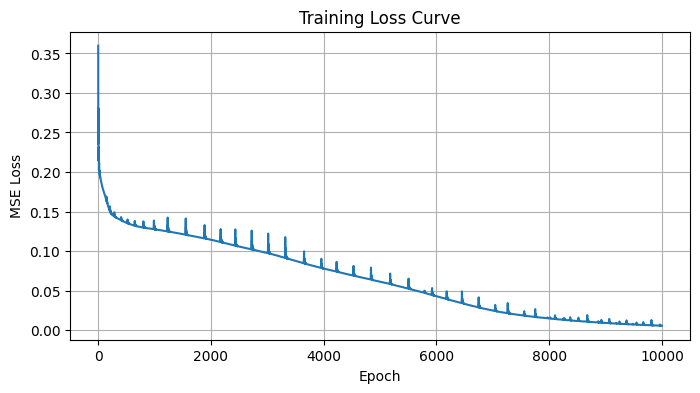

In [11]:
model = NN(input_dim=imu_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

X_train = torch.tensor(imu_train, dtype=torch.float32).to(device)
y_train = torch.tensor(gps_train, dtype=torch.float32).to(device)

n_epochs = 10000

losses = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    # if (epoch+1) % 100 == 0 or epoch == 0:
    #     print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.6f}")

plt.figure(figsize=(8,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

## Physics-informed NN

In [12]:
class PINN(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 3)  # Δp
        )

    def forward(self, x):
        return self.net(x)

In [16]:
ts_train.shape

torch.Size([500])

In [ ]:
# Physics-informed loss: combine MSE with physics-based regularization (e.g., acceleration integration)
def physics_loss(y_pred, imu_batch, dt):
    # y_pred: predicted Δp (N,3)
    # imu_batch: input IMU (N,6) [ax,ay,az,wx,wy,wz]
    # Physics: Δp ≈ v0*dt + 0.5*a*dt^2 (assuming v0=0 for short intervals)
    a = imu_batch[:, :3]  # acceleration
    dt2 = (dt**2).unsqueeze(1).to(device)
    delta_p_physics = 0.5 * a * dt2
    return torch.mean((y_pred - delta_p_physics)**2)

model_pinn = PINN(input_dim=imu_train.shape[1]).to(device)
optimizer_pinn = torch.optim.Adam(model_pinn.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

n_epochs_pinn = 10000
lambda_phys = 0.1  # weight for physics loss

ts_train = torch.tensor(ts_train, dtype=torch.float32)

losses_pinn = []
for epoch in range(n_epochs_pinn):
    model_pinn.train()
    optimizer_pinn.zero_grad()
    y_pred = model_pinn(X_train)
    mse_loss = loss_fn(y_pred, y_train)
    phys_loss = physics_loss(y_pred, X_train, ts_train)
    total_loss = mse_loss + lambda_phys * phys_loss
    total_loss.backward()
    optimizer_pinn.step()
    losses_pinn.append(total_loss.item())
    # if (epoch+1) % 50 == 0 or epoch == 0:
    #     print(f"PINN Epoch {epoch+1}/{n_epochs_pinn}, Loss: {total_loss.item():.6f}, MSE: {mse_loss.item():.6f}, Phys: {phys_loss.item():.6f}")

plt.figure(figsize=(8,4))
plt.plot(losses_pinn)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("PINN Training Loss Curve")
plt.grid(True)
plt.show()


/var/folders/dc/vd1xl3r13qjf5ndxzl0w_r_80000gn/T/ipykernel_90315/2056253051.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ts_train = torch.tensor(ts_train, dtype=torch.float32)


torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([500, 1])
torch.Size([500, 3]) torch.Size([5

In [28]:
torch.ones(100, 3) * torch.zeros(100, 1)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0

In [141]:
gps_test = gps_m[data_end:]
imu_test = imu[data_end:]
ts_test = dt[data_end:]

with torch.no_grad():
    model.eval()
    _gps_pred_normal = model(torch.tensor(imu_test, dtype=torch.float32).to(device)).cpu().numpy()
    model_pinn.eval()
    _gps_pred_pinn = model_pinn(torch.tensor(imu_test, dtype=torch.float32).to(device)).cpu().numpy()


In [146]:
gps_recovered = np.cumsum(gps_train, axis=0)

gps_pred_normal = np.concatenate([gps_train, _gps_pred_normal], axis=0)
gps_pred_pinn = np.concatenate([gps_train, _gps_pred_pinn], axis=0)
gps_pred_normal = np.cumsum(gps_pred_normal, axis=0)
gps_pred_pinn = np.cumsum(gps_pred_pinn, axis=0)


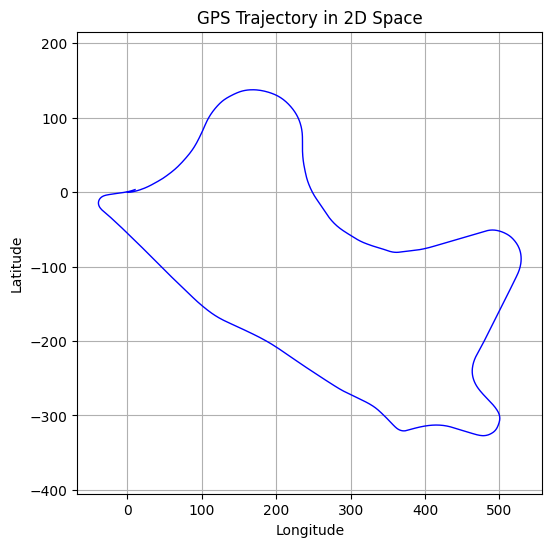

In [147]:
visualize_gps(np.concatenate([gps_recovered, gps_test]))

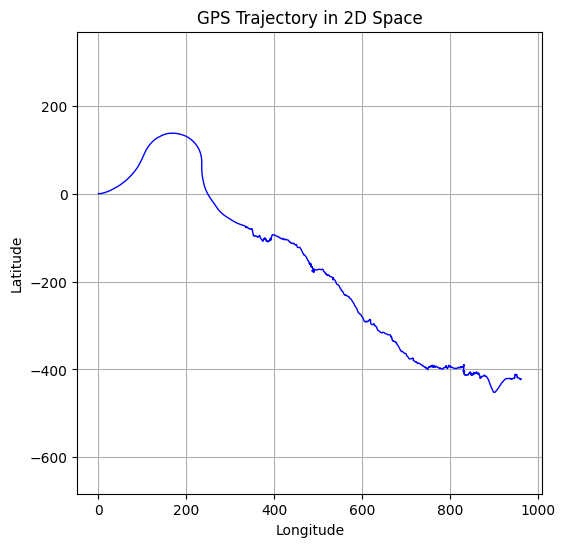

In [148]:
visualize_gps(gps_pred_normal)

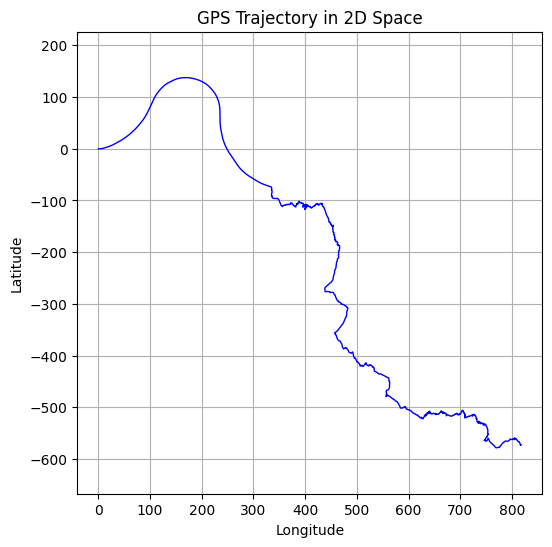

In [149]:
visualize_gps(gps_pred_pinn)